# AI-Powered Athlete Intelligence: Recovery Score Prediction

Predicting daily athlete Recovery Score from training load, sleep, and biometric data using regression models.

## 1. Import Libraries

In [3]:
# core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

# plot styling
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_context("notebook", font_scale=1.05)
sns.set_palette("viridis")

## 2. Load Dataset

In [4]:
# load dataset from kaggle input path
DATA_PATH = '/kaggle/input/datasets/sarveshchhetri/athlete-recovery-and-biometric-performance-dataset/athlete_recovery_synthetic.csv'
df = pd.read_csv(DATA_PATH)

## 3. Initial Data Exploration

#### 3.1 Head

In [5]:
df.head()

,Athlete_ID,Day,Day_of_Week,Week,Age,Gender,Sport_Type,Training_Type,Training_Duration_Min,Training_Intensity,Sleep_Duration_Hours,Caffeine_Intake_mg,Stress_Level,Resting_Heart_Rate,HRV_ms,Mood_Score,Muscle_Soreness,Energy_Level,Recovery_Score
0,1000,1,1,1,28,Male,Team Sport,HIIT,46,7.9,7.7,270,High,59,75,4.3,4.8,5.9,51.1
1,1000,2,2,1,28,Male,Team Sport,Cardio,71,7.0,7.3,258,Low,55,79,5.9,4.0,5.8,63.7
2,1000,3,3,1,28,Male,Team Sport,HIIT,45,7.3,7.7,214,Medium,57,77,5.1,4.0,5.6,71.0
3,1000,4,4,1,28,Male,Team Sport,Cardio,86,7.5,7.9,228,High,61,71,3.0,6.2,2.7,37.2
4,1000,5,5,1,28,Male,Team Sport,HIIT,28,9.2,6.7,0,High,64,62,3.3,7.4,1.1,12.3


#### 3.2 Tail

In [6]:
df.tail()

,Athlete_ID,Day,Day_of_Week,Week,Age,Gender,Sport_Type,Training_Type,Training_Duration_Min,Training_Intensity,Sleep_Duration_Hours,Caffeine_Intake_mg,Stress_Level,Resting_Heart_Rate,HRV_ms,Mood_Score,Muscle_Soreness,Energy_Level,Recovery_Score
8374,1299,24,3,4,28,Female,Strength,Strength,73,6.1,7.8,228,Medium,59,62,5.7,6.5,3.1,31.9
8375,1299,25,4,4,28,Female,Strength,Strength,56,5.2,6.8,0,Low,54,68,6.7,5.5,4.4,36.1
8376,1299,26,5,4,28,Female,Strength,Strength,50,4.9,7.3,167,Low,58,68,6.0,5.1,3.6,29.4
8377,1299,27,6,4,28,Female,Strength,Yoga,36,4.2,7.0,180,High,56,65,4.7,4.3,2.7,31.5
8378,1299,28,7,4,28,Female,Strength,Yoga,76,4.1,7.7,213,Low,51,86,4.5,2.1,6.2,80.3


#### 3.3 Shape and Columns

In [7]:
print(df.shape)
print(df.columns.tolist())

(8379, 19)
['Athlete_ID', 'Day', 'Day_of_Week', 'Week', 'Age', 'Gender', 'Sport_Type', 'Training_Type', 'Training_Duration_Min', 'Training_Intensity', 'Sleep_Duration_Hours', 'Caffeine_Intake_mg', 'Stress_Level', 'Resting_Heart_Rate', 'HRV_ms', 'Mood_Score', 'Muscle_Soreness', 'Energy_Level', 'Recovery_Score']


#### 3.4 Info

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8379 entries, 0 to 8378
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Athlete_ID             8379 non-null   int64  
 1   Day                    8379 non-null   int64  
 2   Day_of_Week            8379 non-null   int64  
 3   Week                   8379 non-null   int64  
 4   Age                    8379 non-null   int64  
 5   Gender                 8379 non-null   object 
 6   Sport_Type             8379 non-null   object 
 7   Training_Type          8379 non-null   object 
 8   Training_Duration_Min  8379 non-null   int64  
 9   Training_Intensity     8378 non-null   float64
 10  Sleep_Duration_Hours   7775 non-null   float64
 11  Caffeine_Intake_mg     8379 non-null   int64  
 12  Stress_Level           8379 non-null   object 
 13  Resting_Heart_Rate     8379 non-null   int64  
 14  HRV_ms                 8379 non-null   int64  
 15  Mood

#### 3.5 Describe

In [9]:
df.describe()

,Athlete_ID,Day,Day_of_Week,Week,Age,Training_Duration_Min,Training_Intensity,Sleep_Duration_Hours,Caffeine_Intake_mg,Resting_Heart_Rate,HRV_ms,Mood_Score,Muscle_Soreness,Energy_Level,Recovery_Score
count,8379.000000,8379.000000,8379.000000,8379.000000,8379.000000,8379.000000,8378.000000,7775.000000,8379.000000,8379.000000,8379.000000,8379.000000,8379.000000,8379.000000,8379.000000
mean,1149.458647,14.497076,3.998329,2.499821,25.860962,52.789712,6.211506,7.498842,185.348132,57.202888,74.126507,5.177109,5.161953,3.273087,49.061356
std,86.631832,8.078044,2.000417,1.117941,4.531092,21.357704,2.368960,0.693790,112.850208,5.790991,13.981632,1.210072,2.127583,1.679100,27.926347
min,1000.000000,1.000000,1.000000,1.000000,18.000000,10.000000,1.000000,5.000000,0.000000,38.000000,22.000000,1.000000,1.000000,1.000000,0.000000
25%,1074.000000,8.000000,2.000000,2.000000,23.000000,36.000000,4.900000,7.000000,126.000000,53.000000,64.000000,4.400000,3.600000,2.000000,27.800000
50%,1149.000000,14.000000,4.000000,2.000000,26.000000,56.000000,6.600000,7.500000,212.000000,58.000000,74.000000,5.200000,5.200000,3.100000,48.900000
75%,1224.000000,21.000000,6.000000,3.000000,28.000000,69.000000,7.900000,8.000000,268.000000,61.000000,84.000000,6.000000,6.700000,4.300000,69.900000
max,1299.000000,28.000000,7.000000,4.000000,41.000000,115.000000,10.000000,9.500000,400.000000,81.000000,115.000000,9.500000,10.000000,10.000000,100.000000


#### 3.6 Missing Values

In [10]:
df.isnull().sum()

Athlete_ID                 0
Day                        0
Day_of_Week                0
Week                       0
Age                        0
Gender                     0
Sport_Type                 0
Training_Type              0
Training_Duration_Min      0
Training_Intensity         1
Sleep_Duration_Hours     604
Caffeine_Intake_mg         0
Stress_Level               0
Resting_Heart_Rate         0
HRV_ms                     0
Mood_Score                 0
Muscle_Soreness            0
Energy_Level               0
Recovery_Score             0
dtype: int64

## 4. Data Cleaning

#### 4.1 Handle Missing Values

In [11]:
# Training_Intensity: negligible missing - median impute
df['Training_Intensity'] = df['Training_Intensity'].fillna(df['Training_Intensity'].median())

# Sleep_Duration_Hours: impute per-athlete median, fallback to global median
df['Sleep_Duration_Hours'] = df.groupby('Athlete_ID')['Sleep_Duration_Hours'].transform(
    lambda x: x.fillna(x.median())
)
df['Sleep_Duration_Hours'] = df['Sleep_Duration_Hours'].fillna(df['Sleep_Duration_Hours'].median())

df.isnull().sum()

Athlete_ID               0
Day                      0
Day_of_Week              0
Week                     0
Age                      0
Gender                   0
Sport_Type               0
Training_Type            0
Training_Duration_Min    0
Training_Intensity       0
Sleep_Duration_Hours     0
Caffeine_Intake_mg       0
Stress_Level             0
Resting_Heart_Rate       0
HRV_ms                   0
Mood_Score               0
Muscle_Soreness          0
Energy_Level             0
Recovery_Score           0
dtype: int64

#### 4.2 Remove Duplicates

In [12]:
print("Duplicate rows before drop:", df.duplicated().sum())
df = df.drop_duplicates()
print("Shape after dropping duplicates:", df.shape)

Duplicate rows before drop: 0
Shape after dropping duplicates: (8379, 19)


#### 4.3 Outlier Detection and Removal
Only Resting_Heart_Rate and HRV_ms are checked, since these are continuous physiological
measurements at risk of sensor or entry error. Bounded rating scales (Sleep, Mood, Energy,
Soreness) are left untouched, as extreme values there are legitimate signal, not errors.

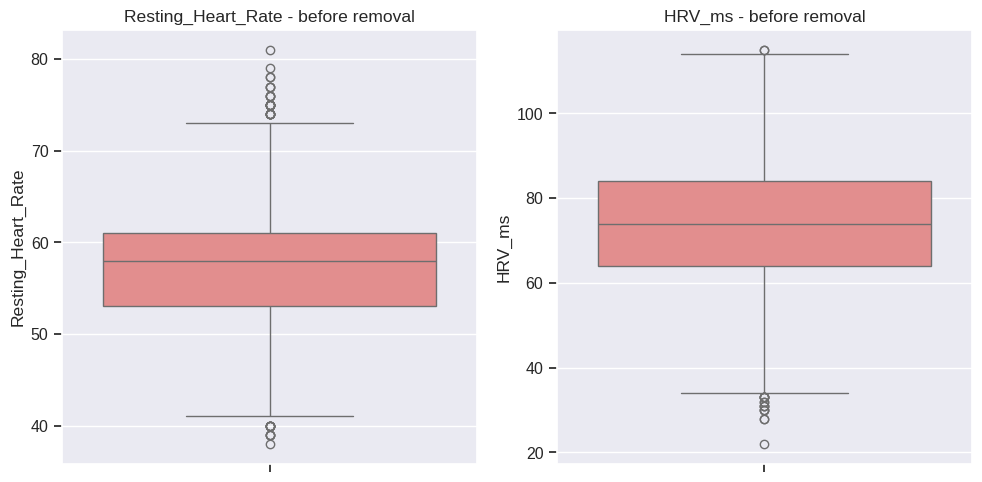

In [13]:
outlier_check_cols = ['Resting_Heart_Rate', 'HRV_ms']

# boxplots before outlier removal
fig, axes = plt.subplots(1, len(outlier_check_cols), figsize=(10, 5))
for ax, col in zip(axes, outlier_check_cols):
    sns.boxplot(y=df[col], ax=ax, color='lightcoral')
    ax.set_title(f'{col} - before removal')
plt.tight_layout()
plt.show()

In [14]:
# IQR based outlier removal
rows_before = df.shape[0]

for col in outlier_check_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers (bounds: {lower:.2f} to {upper:.2f})")
    df = df[(df[col] >= lower) & (df[col] <= upper)]

print("Rows before:", rows_before, "| Rows after:", df.shape[0])

Resting_Heart_Rate: 39 outliers (bounds: 41.00 to 73.00)
HRV_ms: 37 outliers (bounds: 36.50 to 112.50)
Rows before: 8379 | Rows after: 8303


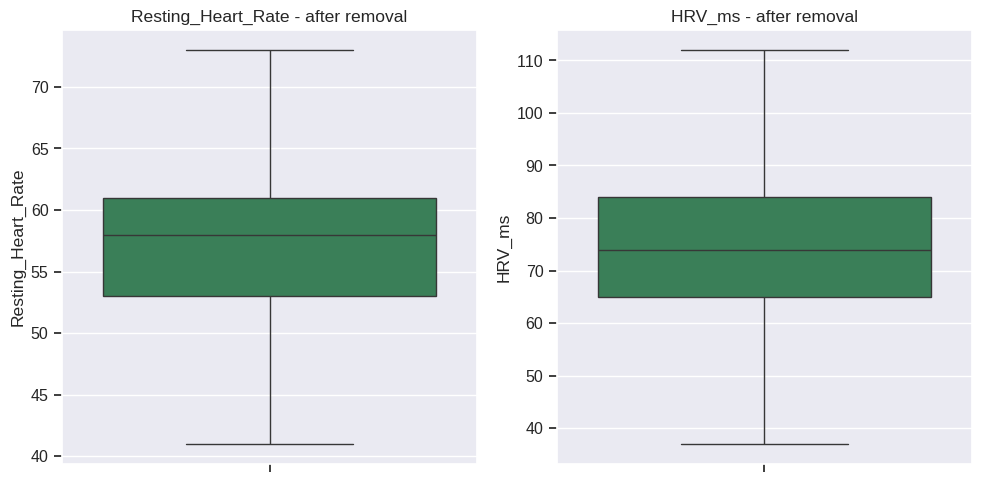

In [15]:
# boxplots after outlier removal
fig, axes = plt.subplots(1, len(outlier_check_cols), figsize=(10, 5))
for ax, col in zip(axes, outlier_check_cols):
    sns.boxplot(y=df[col], ax=ax, color='seagreen')
    ax.set_title(f'{col} - after removal')
plt.tight_layout()
plt.show()

## 5. Exploratory Data Analysis

#### 5.1 Recovery Score Distribution

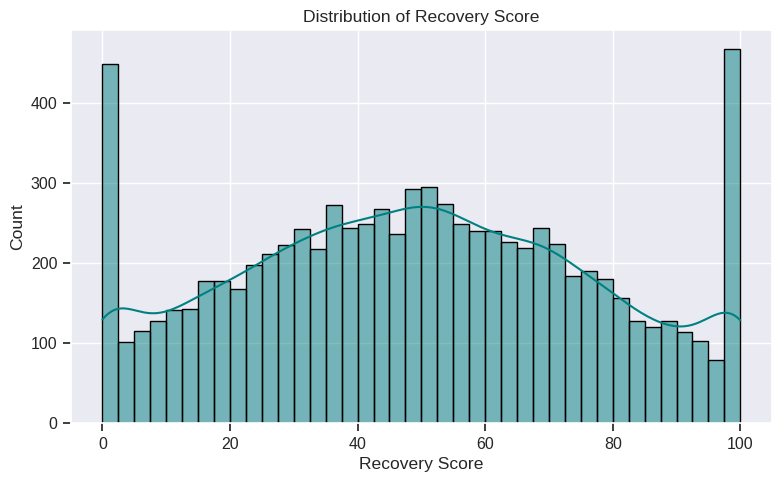

In [16]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Recovery_Score'], bins=40, kde=True, color='teal')
plt.title('Distribution of Recovery Score')
plt.xlabel('Recovery Score')
plt.tight_layout()
plt.show()

#### 5.2 Recovery Score by Training Type

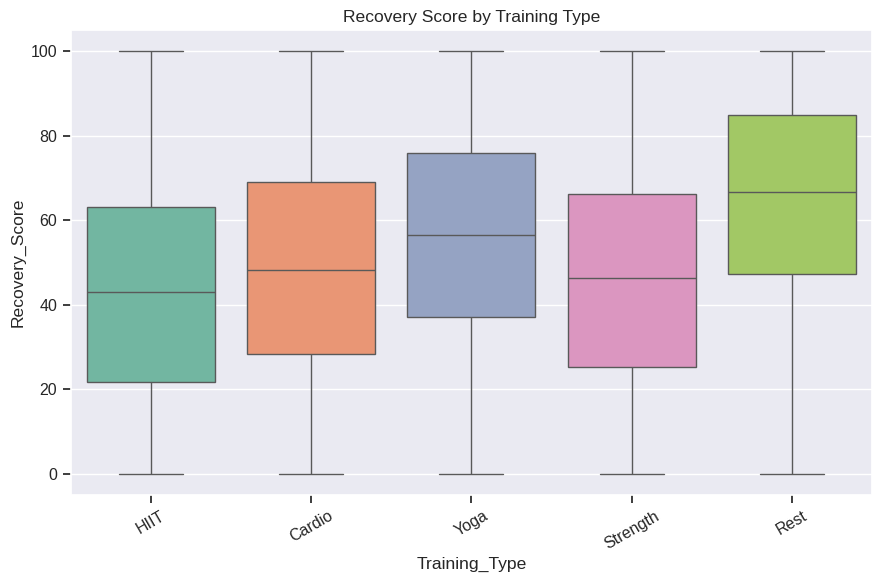

In [17]:
plt.figure(figsize=(9, 6))
sns.boxplot(data=df, x='Training_Type', y='Recovery_Score', hue='Training_Type', palette='Set2', legend=False)
plt.title('Recovery Score by Training Type')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

#### 5.3 HRV vs Recovery Score

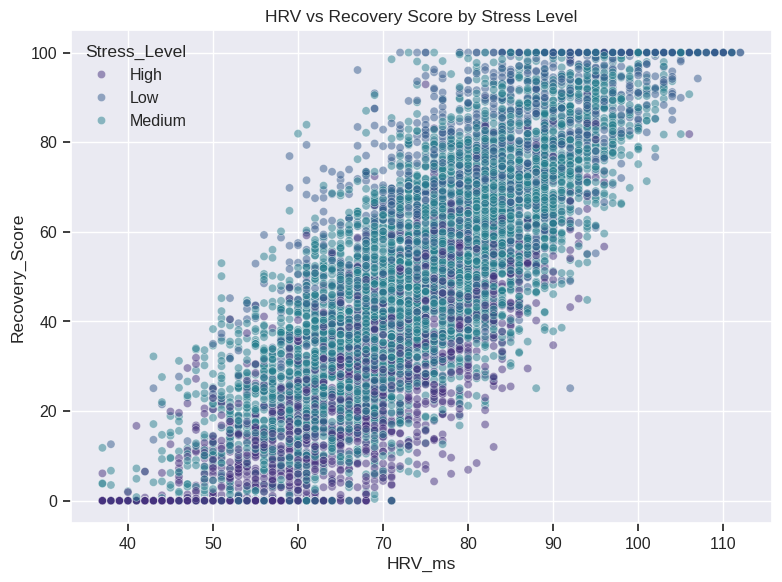

In [18]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='HRV_ms', y='Recovery_Score', alpha=0.5, hue='Stress_Level')
plt.title('HRV vs Recovery Score by Stress Level')
plt.tight_layout()
plt.show()

#### 5.4 Sleep Duration vs Recovery Score

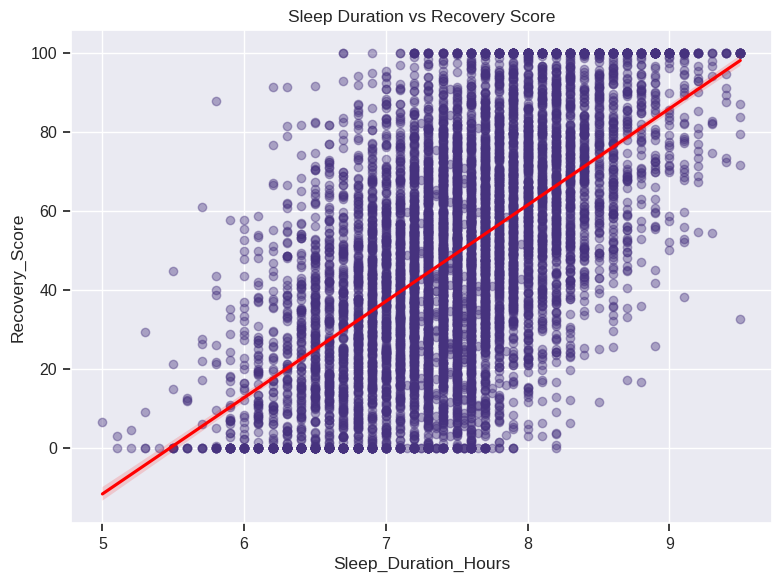

In [19]:
plt.figure(figsize=(8, 6))
sns.regplot(data=df, x='Sleep_Duration_Hours', y='Recovery_Score',
            scatter_kws={'alpha': 0.4}, line_kws={'color': 'red'})
plt.title('Sleep Duration vs Recovery Score')
plt.tight_layout()
plt.show()

#### 5.5 Recovery Score Trend Over 28 Days

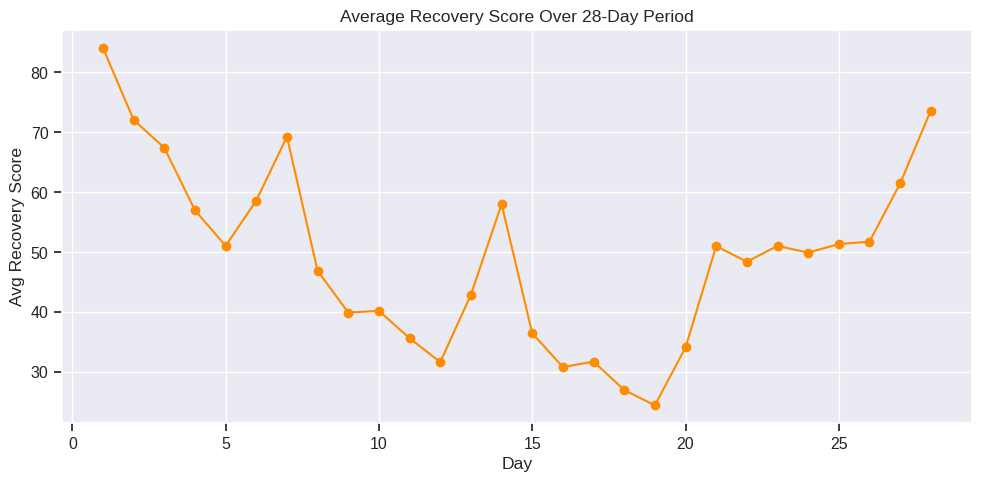

In [20]:
plt.figure(figsize=(10, 5))
df.groupby('Day')['Recovery_Score'].mean().plot(kind='line', marker='o', color='darkorange')
plt.title('Average Recovery Score Over 28-Day Period')
plt.xlabel('Day')
plt.ylabel('Avg Recovery Score')
plt.tight_layout()
plt.show()

#### 5.6 Correlation Heatmap

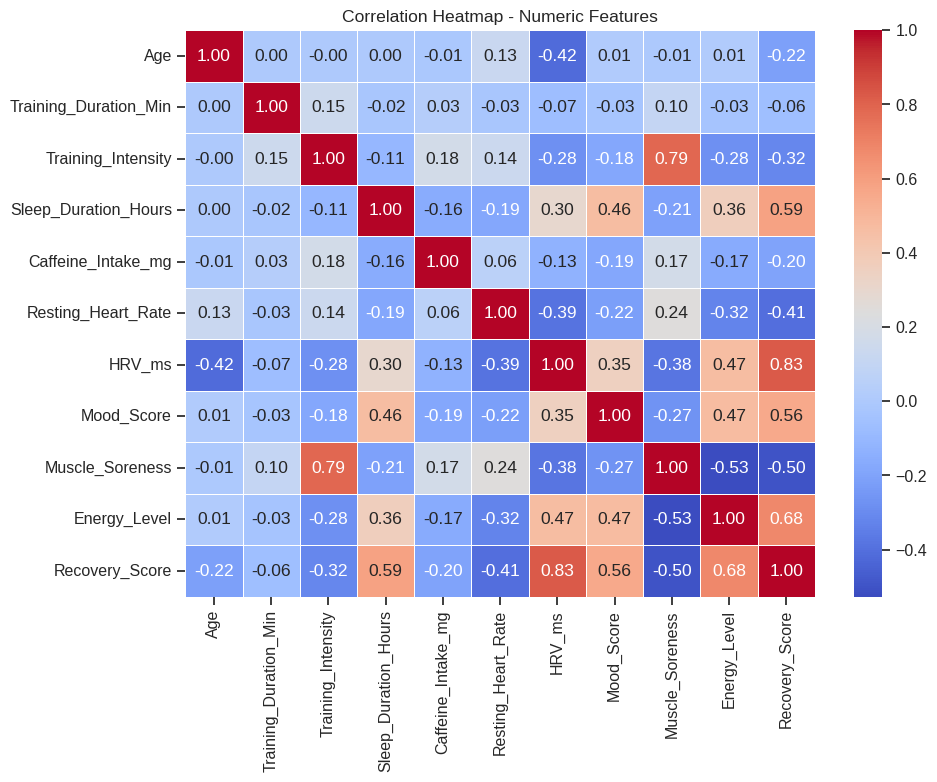

In [21]:
plt.figure(figsize=(10, 8))
numeric_cols = ['Age', 'Training_Duration_Min', 'Training_Intensity', 'Sleep_Duration_Hours',
                 'Caffeine_Intake_mg', 'Resting_Heart_Rate', 'HRV_ms', 'Mood_Score',
                 'Muscle_Soreness', 'Energy_Level', 'Recovery_Score']
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap - Numeric Features')
plt.tight_layout()
plt.show()

## 6. Feature Engineering and Encoding

Training_Load and Sleep_Deficit are engineered, and categorical columns are label encoded.

In [22]:
# engineered features
df['Training_Load'] = df['Training_Duration_Min'] * df['Training_Intensity']
df['Sleep_Deficit'] = 8 - df['Sleep_Duration_Hours']

# encode categoricals
le_gender = LabelEncoder()
df['Gender_enc'] = le_gender.fit_transform(df['Gender'])

le_sport_type = LabelEncoder()
df['Sport_Type_enc'] = le_sport_type.fit_transform(df['Sport_Type'])

le_training_type = LabelEncoder()
df['Training_Type_enc'] = le_training_type.fit_transform(df['Training_Type'])

le_stress = LabelEncoder()
df['Stress_Level_enc'] = le_stress.fit_transform(df['Stress_Level'])

df.head()

,Athlete_ID,Day,Day_of_Week,Week,Age,Gender,Sport_Type,Training_Type,Training_Duration_Min,Training_Intensity,...,Mood_Score,Muscle_Soreness,Energy_Level,Recovery_Score,Training_Load,Sleep_Deficit,Gender_enc,Sport_Type_enc,Training_Type_enc,Stress_Level_enc
0,1000,1,1,1,28,Male,Team Sport,HIIT,46,7.9,...,4.3,4.8,5.9,51.1,363.4,0.3,1,4,1,0
1,1000,2,2,1,28,Male,Team Sport,Cardio,71,7.0,...,5.9,4.0,5.8,63.7,497.0,0.7,1,4,0,1
2,1000,3,3,1,28,Male,Team Sport,HIIT,45,7.3,...,5.1,4.0,5.6,71.0,328.5,0.3,1,4,1,2
3,1000,4,4,1,28,Male,Team Sport,Cardio,86,7.5,...,3.0,6.2,2.7,37.2,645.0,0.1,1,4,0,0
4,1000,5,5,1,28,Male,Team Sport,HIIT,28,9.2,...,3.3,7.4,1.1,12.3,257.6,1.3,1,4,1,0


## 7. Train-Test Split and Scaling

In [23]:
features = ['Age', 'Gender_enc', 'Sport_Type_enc', 'Training_Type_enc',
            'Training_Duration_Min', 'Training_Intensity', 'Training_Load',
            'Sleep_Duration_Hours', 'Sleep_Deficit', 'Caffeine_Intake_mg',
            'Stress_Level_enc', 'Resting_Heart_Rate', 'HRV_ms',
            'Mood_Score', 'Muscle_Soreness', 'Energy_Level']
target = 'Recovery_Score'

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)

Train shape: (6642, 16) | Test shape: (1661, 16)


#### 7.1 Helper Functions for Evaluation and Plotting

In [24]:
# shared containers for results across all model sections below
results = []
predictions = {}
fitted_models = {}

def plot_actual_vs_predicted(name, y_test, y_pred):
    errors = np.abs(y_test.values - y_pred)
    fig, ax = plt.subplots(figsize=(8, 7))
    ax.scatter(y_test, y_pred, s=180, c=errors, cmap='plasma', alpha=0.12, linewidths=0)
    scatter = ax.scatter(y_test, y_pred, s=45, c=errors, cmap='plasma',
                          alpha=0.85, edgecolors='white', linewidths=0.4)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
            color='red', linestyle='--', linewidth=2.5, label='Perfect Prediction')
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Absolute Error', fontsize=10)
    ax.set_xlabel('Actual Recovery Score', fontsize=11)
    ax.set_ylabel('Predicted Recovery Score', fontsize=11)
    ax.set_title(f'Actual vs Predicted - {name}', fontsize=13, fontweight='bold')
    ax.legend(loc='upper left')
    plt.tight_layout()
    plt.show()

def evaluate_model(name, model, y_test, y_pred):
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2})
    predictions[name] = y_pred
    fitted_models[name] = model
    print(f"MAE  : {mae:.3f}")
    print(f"RMSE : {rmse:.3f}")
    print(f"R2   : {r2:.4f}")

## 8. Model Training and Evaluation

#### 8.1 Linear Regression

In [25]:
model_lr = LinearRegression()
model_lr.fit(X_train_scaled, y_train)
y_pred_lr = model_lr.predict(X_test_scaled)
evaluate_model('Linear Regression', model_lr, y_test, y_pred_lr)

MAE  : 7.404
RMSE : 9.289
R2   : 0.8872


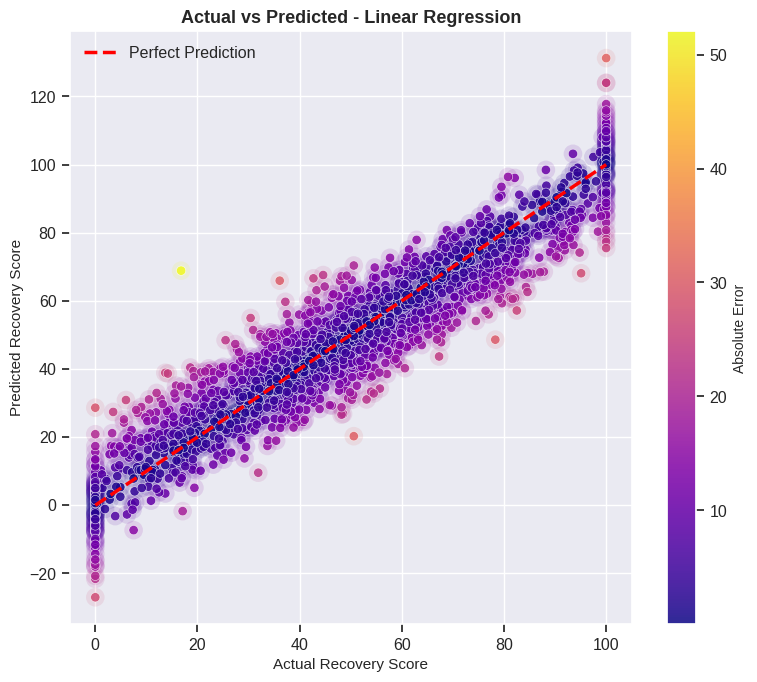

In [26]:
plot_actual_vs_predicted('Linear Regression', y_test, y_pred_lr)

#### 8.2 Random Forest

In [27]:
model_rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)
evaluate_model('Random Forest', model_rf, y_test, y_pred_rf)

MAE  : 7.210
RMSE : 9.245
R2   : 0.8883


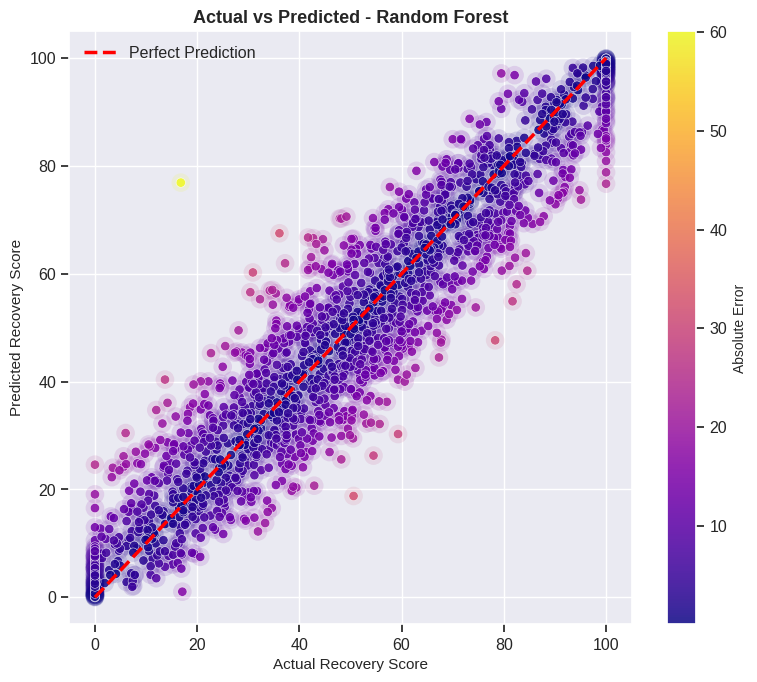

In [28]:
plot_actual_vs_predicted('Random Forest', y_test, y_pred_rf)

#### 8.3 XGBoost

In [29]:
model_xgb = xgb.XGBRegressor(n_estimators=200, random_state=42)
model_xgb.fit(X_train, y_train)
y_pred_xgb = model_xgb.predict(X_test)
evaluate_model('XGBoost', model_xgb, y_test, y_pred_xgb)

MAE  : 7.832
RMSE : 9.956
R2   : 0.8705


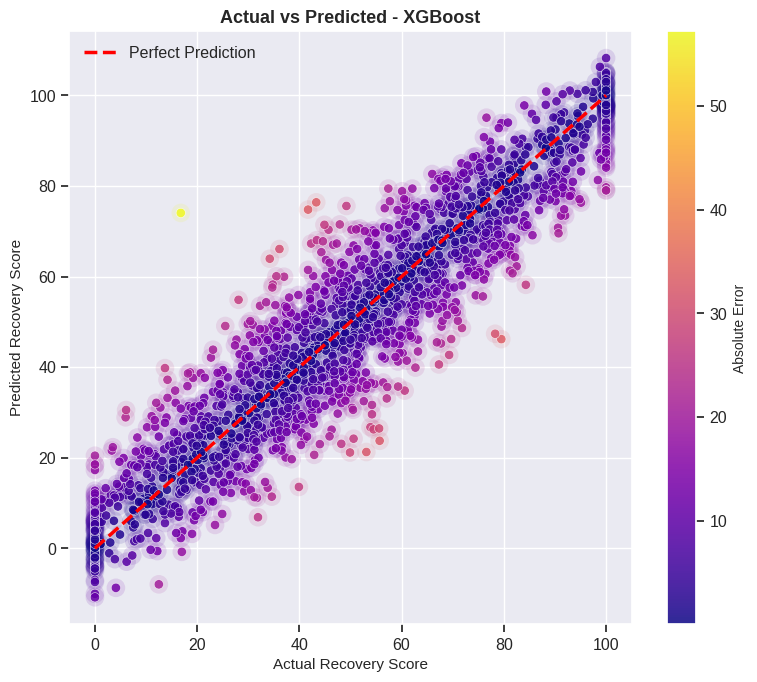

In [30]:
plot_actual_vs_predicted('XGBoost', y_test, y_pred_xgb)

#### 8.4 Gradient Boosting

In [31]:
model_gb = GradientBoostingRegressor(n_estimators=150, random_state=42)
model_gb.fit(X_train, y_train)
y_pred_gb = model_gb.predict(X_test)
evaluate_model('Gradient Boosting', model_gb, y_test, y_pred_gb)

MAE  : 7.090
RMSE : 8.979
R2   : 0.8946


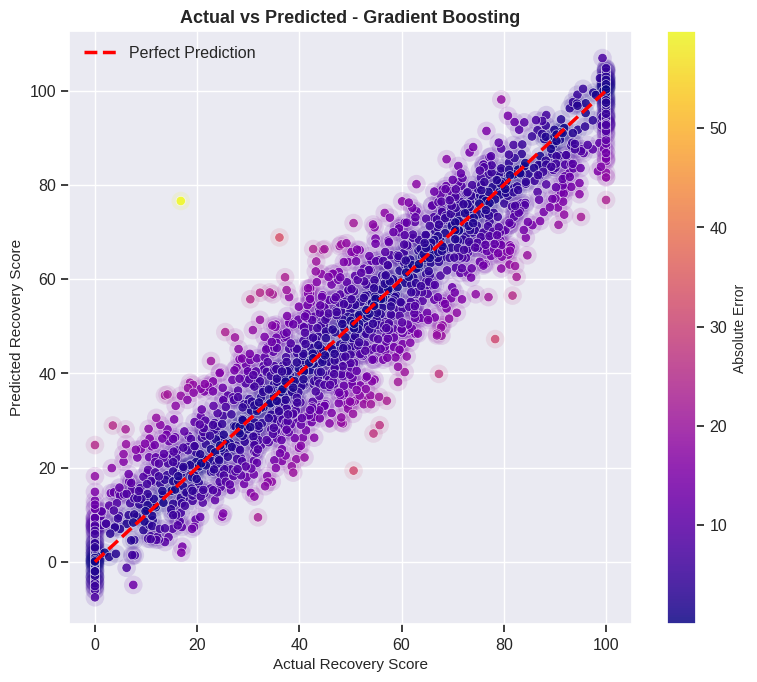

In [32]:
plot_actual_vs_predicted('Gradient Boosting', y_test, y_pred_gb)

#### 8.5 KNN

In [33]:
model_knn = KNeighborsRegressor(n_neighbors=7)
model_knn.fit(X_train_scaled, y_train)
y_pred_knn = model_knn.predict(X_test_scaled)
evaluate_model('KNN', model_knn, y_test, y_pred_knn)

MAE  : 9.008
RMSE : 11.395
R2   : 0.8303


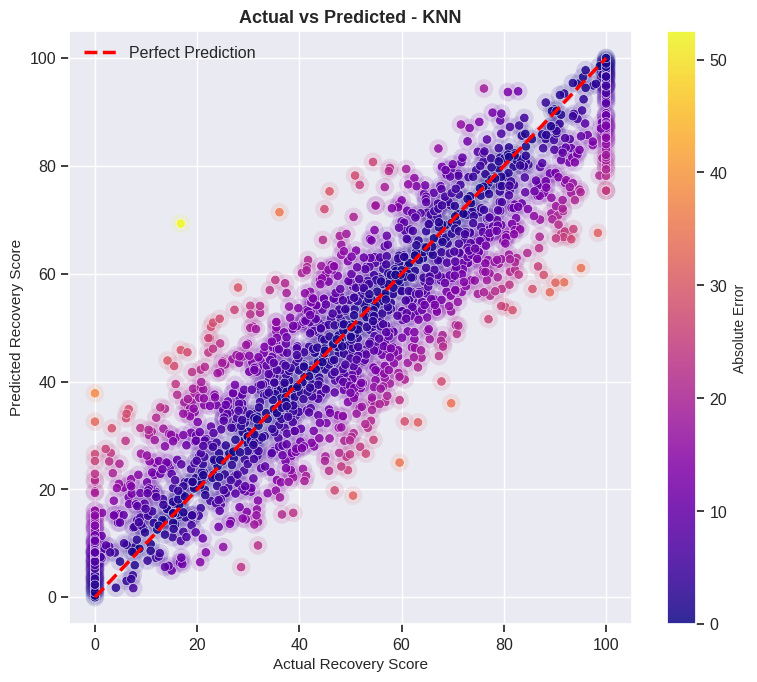

In [34]:
plot_actual_vs_predicted('KNN', y_test, y_pred_knn)

## 9. Model Comparison

#### 9.1 Comparison Table

In [35]:
results_df = pd.DataFrame(results).sort_values(by='R2', ascending=False).reset_index(drop=True)
results_df

,Model,MAE,RMSE,R2
0,Gradient Boosting,7.090133,8.979374,0.894623
1,Random Forest,7.210197,9.244746,0.888303
2,Linear Regression,7.403893,9.289250,0.887225
3,XGBoost,7.832150,9.955745,0.870461
4,KNN,9.007646,11.395033,0.830299


#### 9.2 Metric Comparison Charts

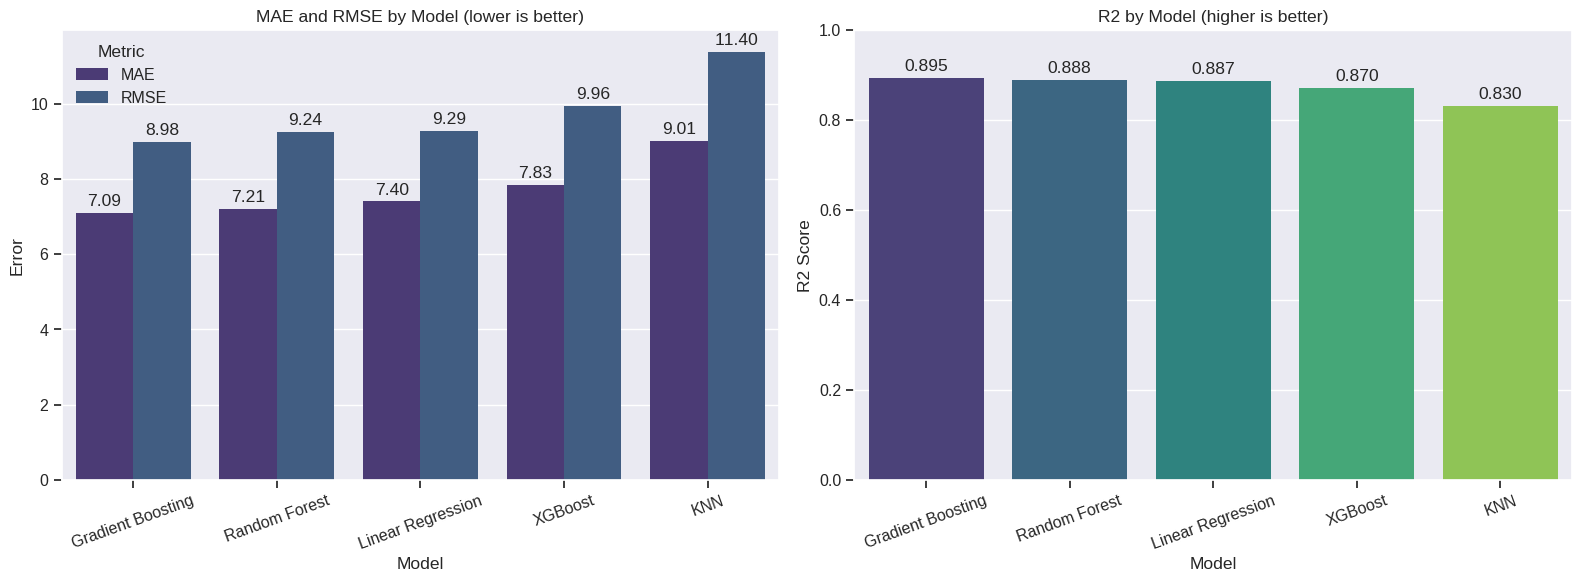

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# MAE and RMSE together - same unit scale
error_melted = results_df.melt(id_vars='Model', value_vars=['MAE', 'RMSE'],
                                var_name='Metric', value_name='Value')
ax1 = sns.barplot(data=error_melted, x='Model', y='Value', hue='Metric', ax=axes[0])
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.2f', padding=3)
axes[0].set_title('MAE and RMSE by Model (lower is better)')
axes[0].set_ylabel('Error')
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend(title='Metric')

# R2 on its own scale
ax2 = sns.barplot(data=results_df, x='Model', y='R2', hue='Model', palette='viridis',
                   legend=False, ax=axes[1])
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.3f', padding=3)
axes[1].set_title('R2 by Model (higher is better)')
axes[1].set_ylabel('R2 Score')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## 10. Feature Importance - Best Model

Feature importance is shown for the best performing model based on R2 score.

Best model: Gradient Boosting


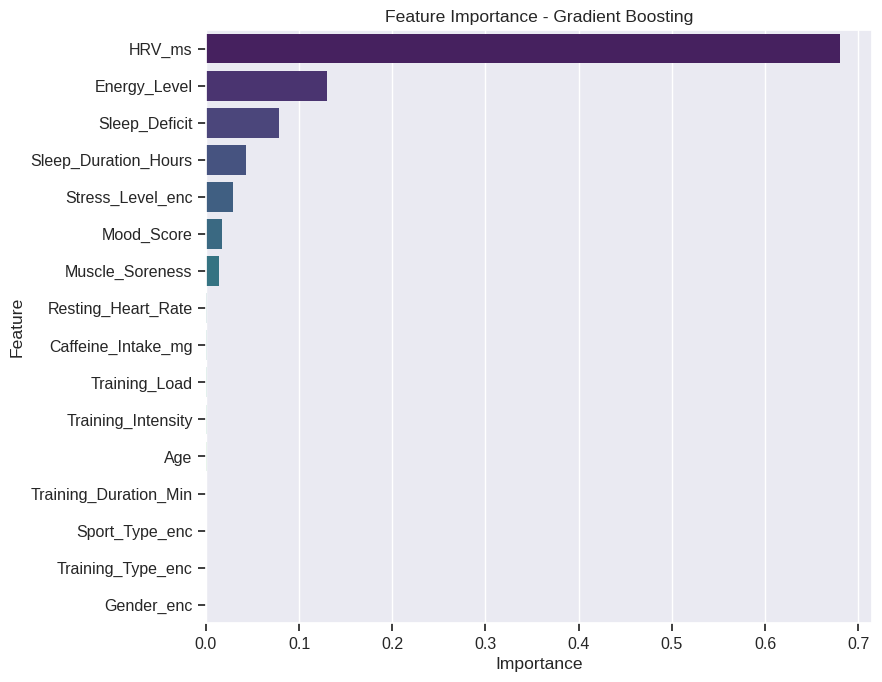

In [37]:
best_model_name = results_df.iloc[0]['Model']
best_model = fitted_models[best_model_name]
print("Best model:", best_model_name)

if hasattr(best_model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'Feature': features,
        'Importance': best_model.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(9, 7))
    sns.barplot(data=importance_df, x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)
    plt.title(f'Feature Importance - {best_model_name}')
    plt.tight_layout()
    plt.show()

    importance_df
else:
    print(f"{best_model_name} does not expose feature importances.")

## 11. Residual Analysis - Best Model

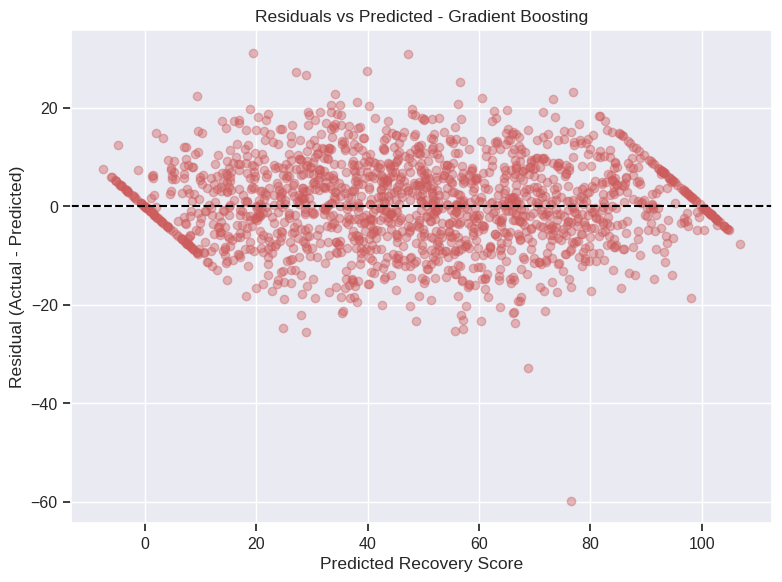

In [38]:
best_y_pred = predictions[best_model_name]
residuals = y_test - best_y_pred

plt.figure(figsize=(8, 6))
plt.scatter(best_y_pred, residuals, alpha=0.4, color='indianred')
plt.axhline(y=0, color='black', linestyle='--')
plt.xlabel('Predicted Recovery Score')
plt.ylabel('Residual (Actual - Predicted)')
plt.title(f'Residuals vs Predicted - {best_model_name}')
plt.tight_layout()
plt.show()

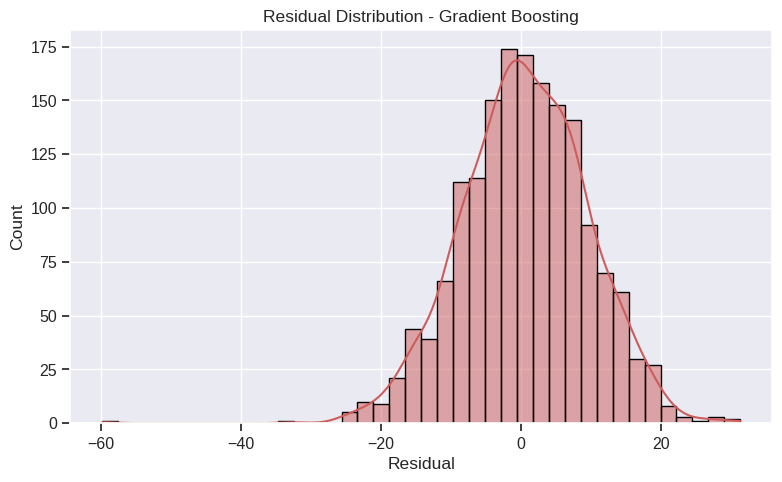

Residual mean: 0.514 | Residual std: 8.967


In [39]:
plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=40, kde=True, color='indianred')
plt.title(f'Residual Distribution - {best_model_name}')
plt.xlabel('Residual')
plt.tight_layout()
plt.show()

print("Residual mean:", round(residuals.mean(), 3), "| Residual std:", round(residuals.std(), 3))